# Experiments notebook

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.ML.config import FULL_FEATURES, RANDOM_STATE, TEST_SIZE, CV_FOLDS
from src.ML.pipelines import create_LR_pipeline, create_RF_pipeline, create_SVR_pipeline
from src.ML.evaluation import train_and_evaluate
from src.ML.visualization import residual_analysis
from src.ML.tunning import tune_RF, tune_SVR
from sklearn.decomposition import PCA



## Load data/Generate random data

In [2]:
from sklearn.model_selection import train_test_split


def make_random_data(n_samples=200):
    X=pd.DataFrame(
        np.random.randn(n_samples,len(FULL_FEATURES)),
                        columns=FULL_FEATURES
    )
    y=np.random.uniform(0,10,n_samples)
    return X,y

x,y=make_random_data()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

## PCA?


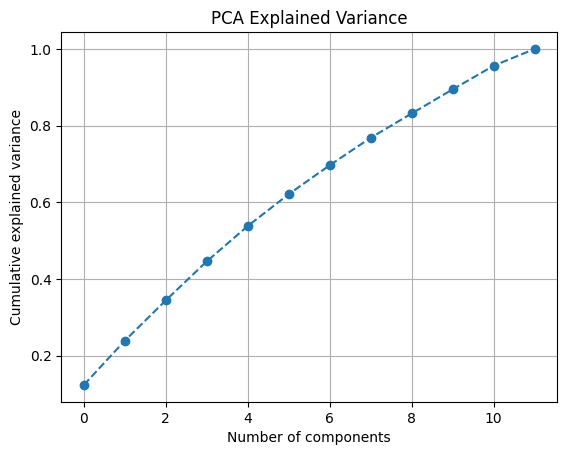

In [3]:
pca = PCA()
pca.fit(X_train)

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    linestyle='--',   
    marker='o'        #
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(True)

plt.show()

## Run model (baseline)


In [4]:
pipeline_lr=create_LR_pipeline()
pipeline_rf=create_RF_pipeline()
pipeline_svr=create_SVR_pipeline()

metrics_lr,y_pred_lr=train_and_evaluate(pipeline_lr, X_train, y_train, X_test, y_test)
metrics_rf,y_pred_rf=train_and_evaluate(pipeline_rf, X_train, y_train, X_test, y_test)
metrics_svr,y_pred_svr=train_and_evaluate(pipeline_svr, X_train, y_train, X_test, y_test)
print("LR Metrics:", metrics_lr)
print("RF Metrics:", metrics_rf)
print("SVR Metrics:", metrics_svr)

LR Metrics: {'MSE': 8.41928645170297, 'R2': -0.08478681763653029, 'MAE': 2.5089392365817305}
RF Metrics: {'MSE': 8.805301928123924, 'R2': -0.1345231584330162, 'MAE': 2.541147928556522}
SVR Metrics: {'MSE': 8.851184054176821, 'R2': -0.1404348619714142, 'MAE': 2.5953122801600683}


In [5]:
results = []
results.append({"Model": "Linear Regression", **metrics_lr})
results.append({"Model": "Random Forest", **metrics_rf})
results.append({"Model": "SVR", **metrics_svr})

results_df = pd.DataFrame(results)
results_df

,Model,MSE,R2,MAE
0,Linear Regression,8.419286,-0.084787,2.508939
1,Random Forest,8.805302,-0.134523,2.541148
2,SVR,8.851184,-0.140435,2.595312


## PLOTS

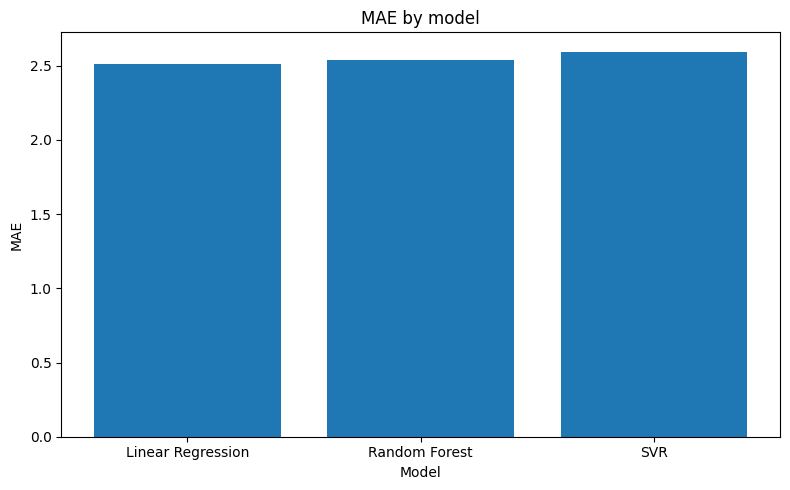

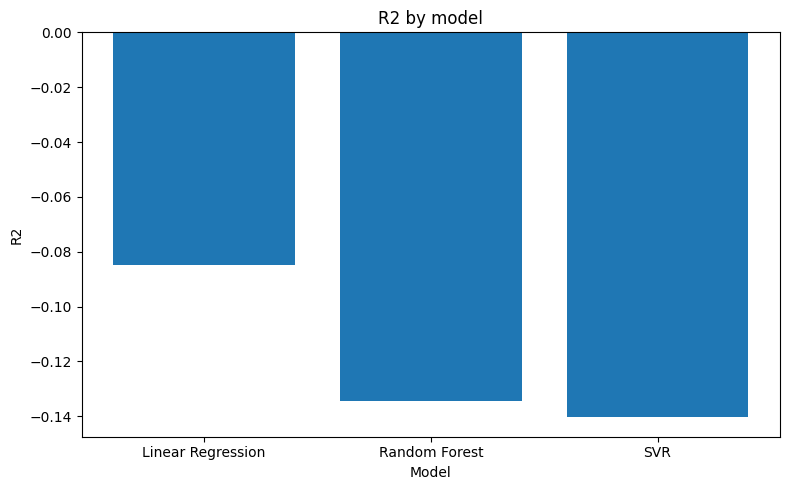

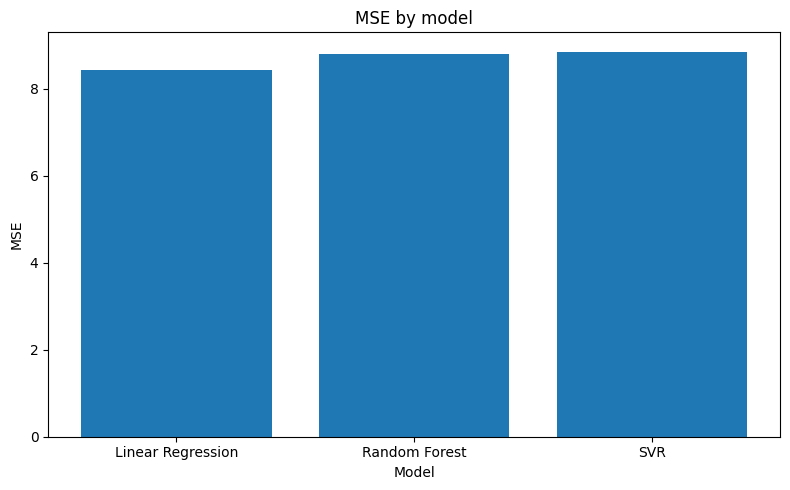

In [6]:
def plot_metric_by_model(results_df, metric="MAE", feature_set=None):
    df_plot = results_df.copy()

    if feature_set is not None:
        df_plot = df_plot[df_plot["feature_set"] == feature_set]

    plt.figure(figsize=(8, 5))
    plt.bar(df_plot["Model"], df_plot[metric])
    plt.xlabel("Model")
    plt.ylabel(metric)
    title = f"{metric} by model"
    if feature_set is not None:
        title += f" ({feature_set})"
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_metric_by_model(results_df, metric="MAE")
plot_metric_by_model(results_df, metric="R2")
plot_metric_by_model(results_df, metric="MSE")

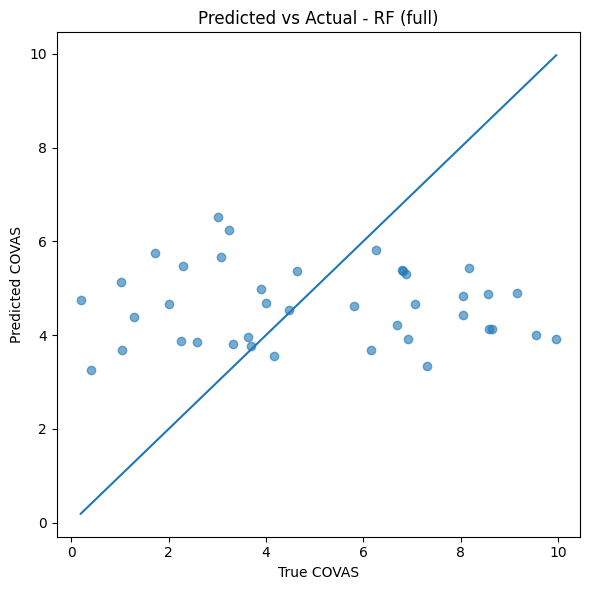

In [7]:
def plot_predicted_vs_actual(y_true, y_pred, model_name="Model", feature_set="full"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("True COVAS")
    plt.ylabel("Predicted COVAS")
    plt.title(f"Predicted vs Actual - {model_name} ({feature_set})")
    plt.tight_layout()
    plt.show()

plot_predicted_vs_actual(y_test, y_pred_rf, model_name="RF", feature_set="full")

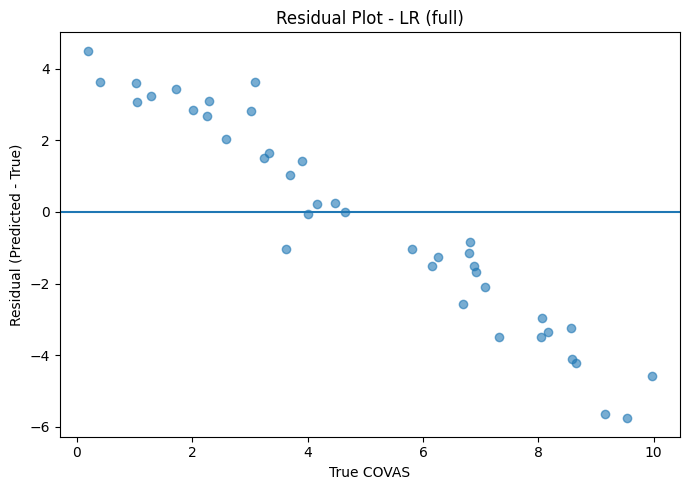

In [8]:
def plot_residuals(y_true, y_pred, model_name="Model", feature_set="full"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_pred - y_true

    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, residuals, alpha=0.6)
    
    plt.axhline(0)  # zero-error line
    
    plt.xlabel("True COVAS")
    plt.ylabel("Residual (Predicted - True)")
    plt.title(f"Residual Plot - {model_name} ({feature_set})")
    
    plt.tight_layout()
    plt.show()

plot_residuals(y_test, y_pred_lr, model_name="LR", feature_set="full")

### LINEAR REGRESSION ASSUMPTIONS

1. Residues follow a **normal distribution**
2. Residues have **zero mean** and **constant variance**
3. Residues are **independent** (aka no real structure)
4. **Linearity**  (check resiudals vs fitted values)

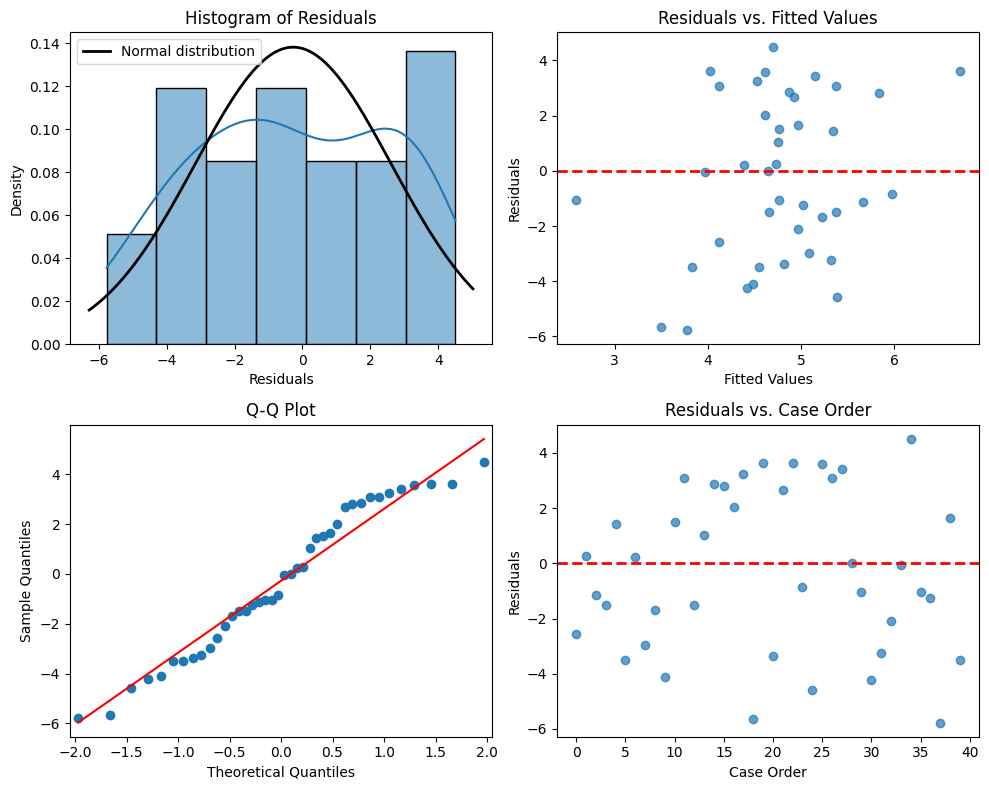

In [9]:
residual_analysis(y_test, y_pred_lr)

### SVR tunnnig


In [10]:
grid_svr = tune_SVR(X_train, y_train)
print(grid_svr.best_params_)
best_svr = grid_svr.best_estimator_
print(grid_svr.best_score_)

{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'poly'}
-2.7870421650410764


### Random Forest tunning

In [11]:
grid_rf = tune_RF(X_train, y_train)

print(grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
print(grid_rf.best_score_)

{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
-2.8994106469484775
